# 08. Robust Inference Strategy

Notebook này ghi lại kết quả của **Stage 8 — Robust Inference Strategy**.

Ý tưởng chính:

```text
Dùng PhoBERT làm mô hình mặc định.
Nếu đầu vào bị phát hiện là thiếu dấu, chuyển sang TF-IDF char SVM.
```

Notebook này **không train lại PhoBERT** và **không train lại SVM**.  
Nó đọc lại prediction đã có từ Stage 5 và Stage 6, sau đó đánh giá chiến lược suy luận mới.

Các hệ thống được so sánh:

```text
1. phobert_only
2. tfidf_char_svm_only
3. robust_router
4. oracle_router
```

Trong đó:

```text
robust_router:
- Hệ thống thực tế.
- Dùng detector để quyết định route sang PhoBERT hoặc TF-IDF char SVM.

oracle_router:
- Upper bound tham khảo.
- Biết trước variant nào là no_accent/mixed_no_accent.
- Không phải hệ thống triển khai thực tế.
```

## 1. Setup

In [2]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image

cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd

print("Project root:", ROOT)

TABLES_DIR = ROOT / "outputs" / "tables"
FIGURES_DIR = ROOT / "outputs" / "figures"
REPORTS_DIR = ROOT / "outputs" / "reports"
METRICS_DIR = ROOT / "outputs" / "metrics"
PREDICTIONS_DIR = ROOT / "outputs" / "predictions"
NOISY_DIR = ROOT / "data" / "noisy"

Project root: d:\project-ml-engineering\viedufeedback-robust


## 2. Kiểm tra file Stage 8 bắt buộc

Các file này được tạo bởi hai lệnh:

```powershell
python scripts/generate_noisy_validation.py
python scripts/evaluate_robust_inference.py
```

In [3]:
required_files = {
    "robust_config": ROOT / "configs" / "robust_inference.yaml",
    "robust_source": ROOT / "src" / "robust_inference.py",
    "generate_noisy_validation_script": ROOT / "scripts" / "generate_noisy_validation.py",
    "evaluate_robust_inference_script": ROOT / "scripts" / "evaluate_robust_inference.py",

    "validation_eval_all": NOISY_DIR / "validation_eval_all.csv",

    "noisy_validation_generation_summary": TABLES_DIR / "noisy_validation_generation_summary.csv",
    "noisy_validation_detection_thresholds": TABLES_DIR / "noisy_validation_detection_thresholds.csv",

    "selected_threshold": METRICS_DIR / "robust_inference_selected_threshold.json",

    "robust_inference_predictions": PREDICTIONS_DIR / "robust_inference_predictions.csv",
    "robust_inference_results": TABLES_DIR / "robust_inference_results.csv",
    "robust_inference_drop": TABLES_DIR / "robust_inference_drop.csv",
    "robust_inference_comparison": TABLES_DIR / "robust_inference_comparison.csv",
    "robust_inference_class_report": TABLES_DIR / "robust_inference_class_report.csv",
    "robust_inference_detector_overall": TABLES_DIR / "robust_inference_detector_overall.csv",
    "robust_inference_detector_by_variant": TABLES_DIR / "robust_inference_detector_by_variant.csv",

    "robust_inference_macro_f1_sentiment": FIGURES_DIR / "robust_inference_macro_f1_sentiment.png",
    "robust_inference_macro_f1_topic": FIGURES_DIR / "robust_inference_macro_f1_topic.png",
    "robust_inference_drop_sentiment": FIGURES_DIR / "robust_inference_drop_sentiment.png",
    "robust_inference_drop_topic": FIGURES_DIR / "robust_inference_drop_topic.png",

    "robust_inference_report": REPORTS_DIR / "robust_inference_report.md",
    "robust_inference_metrics": METRICS_DIR / "robust_inference_metrics.json",
}

check_df = pd.DataFrame(
    [{"name": name, "path": str(path), "exists": path.exists()} for name, path in required_files.items()]
)

display(check_df)

missing = check_df.loc[~check_df["exists"], "name"].tolist()
if missing:
    raise FileNotFoundError(f"Missing Stage 8 files: {missing}")

print("All required Stage 8 files exist.")

,name,path,exists
0,robust_config,d:\project-ml-engineering\viedufeedback-robust...,True
1,robust_source,d:\project-ml-engineering\viedufeedback-robust...,True
2,generate_noisy_validation_script,d:\project-ml-engineering\viedufeedback-robust...,True
3,evaluate_robust_inference_script,d:\project-ml-engineering\viedufeedback-robust...,True
4,validation_eval_all,d:\project-ml-engineering\viedufeedback-robust...,True
5,noisy_validation_generation_summary,d:\project-ml-engineering\viedufeedback-robust...,True
6,noisy_validation_detection_thresholds,d:\project-ml-engineering\viedufeedback-robust...,True
7,selected_threshold,d:\project-ml-engineering\viedufeedback-robust...,True
8,robust_inference_predictions,d:\project-ml-engineering\viedufeedback-robust...,True
9,robust_inference_results,d:\project-ml-engineering\viedufeedback-robust...,True


All required Stage 8 files exist.


## 3. Load kết quả Stage 8

In [4]:
validation_generation = pd.read_csv(TABLES_DIR / "noisy_validation_generation_summary.csv")
thresholds = pd.read_csv(TABLES_DIR / "noisy_validation_detection_thresholds.csv")
detector_overall = pd.read_csv(TABLES_DIR / "robust_inference_detector_overall.csv")
detector_by_variant = pd.read_csv(TABLES_DIR / "robust_inference_detector_by_variant.csv")

results = pd.read_csv(TABLES_DIR / "robust_inference_results.csv")
drop = pd.read_csv(TABLES_DIR / "robust_inference_drop.csv")
comparison = pd.read_csv(TABLES_DIR / "robust_inference_comparison.csv")
class_report = pd.read_csv(TABLES_DIR / "robust_inference_class_report.csv")

display(Markdown("### Noisy validation generation summary"))
display(validation_generation)

display(Markdown("### Detection threshold candidates"))
display(thresholds)

display(Markdown("### Detector overall"))
display(detector_overall)

display(Markdown("### Detector by variant"))
display(detector_by_variant)

display(Markdown("### Robust inference comparison preview"))
display(comparison.head(30))

### Noisy validation generation summary

,variant,noise_type,noise_level,num_rows,changed_percent
0,clean,clean,none,1583,0.0000
1,no_accent,remove_diacritics,medium,1583,99.7473
2,typo_light,typo,light,1583,100.0000
3,typo_medium,typo,medium,1583,100.0000
4,teencode_light,teencode,light,1583,100.0000
5,mixed_light,mixed,light,1583,100.0000
6,mixed_no_accent,mixed,medium,1583,100.0000


### Detection threshold candidates

,threshold,route_to_char_rate,accuracy,precision,recall,f1,true_positive,false_positive,true_negative,false_negative,false_positive_rate,false_negative_rate
0,0.000,0.263875,0.978161,1.000000,0.923563,0.960263,2924,0,7915,242,0.000000,0.076437
1,0.005,0.263875,0.978161,1.000000,0.923563,0.960263,2924,0,7915,242,0.000000,0.076437
2,0.010,0.264687,0.978973,1.000000,0.926406,0.961797,2933,0,7915,233,0.000000,0.073594
3,0.020,0.267575,0.981861,1.000000,0.936513,0.967216,2965,0,7915,201,0.000000,0.063487
4,0.050,0.271456,0.984839,0.998338,0.948515,0.972789,3003,5,7910,163,0.000632,0.051485
5,0.100,0.273531,0.986012,0.996701,0.954201,0.974988,3021,10,7905,145,0.001263,0.045799


### Detector overall

,scope,accuracy,precision,recall,f1,true_positive,false_positive,true_negative,false_negative,false_positive_rate,false_negative_rate
0,overall,0.984839,0.993904,0.95278,0.972908,6033,37,15793,299,0.002337,0.04722


### Detector by variant

,scope,variant,total,route_to_char_svm,route_to_phobert,route_to_char_rate,true_no_accent_variant,mean_accented_ratio,median_accented_ratio
0,variant,clean,3166,7,3159,0.002211,False,0.275389,0.272727
1,variant,mixed_light,3166,9,3157,0.002843,False,0.271621,0.270270
2,variant,mixed_no_accent,3166,3013,153,0.951674,True,0.000000,0.000000
3,variant,no_accent,3166,3020,146,0.953885,True,0.000000,0.000000
4,variant,teencode_light,3166,7,3159,0.002211,False,0.272048,0.270270
5,variant,typo_light,3166,7,3159,0.002211,False,0.275022,0.272727
6,variant,typo_medium,3166,7,3159,0.002211,False,0.274831,0.272727


### Robust inference comparison preview

,task,system,variant,noise_type,noise_level,num_samples,accuracy,macro_precision,macro_recall,macro_f1,...,macro_f1_drop,macro_f1_relative_drop_percent,rank_macro_f1_within_variant,phobert_only_macro_f1,phobert_only_accuracy,oracle_router_macro_f1,oracle_router_accuracy,macro_f1_gain_vs_phobert,accuracy_gain_vs_phobert,macro_f1_gap_to_oracle
0,sentiment,oracle_router,clean,clean,none,3166,0.931459,0.838886,0.809982,0.822815,...,0.000000,0.0000,1,0.822815,0.931459,0.822815,0.931459,0.000000,0.000000,0.000000
1,sentiment,phobert_only,clean,clean,none,3166,0.931459,0.838886,0.809982,0.822815,...,0.000000,0.0000,1,0.822815,0.931459,0.822815,0.931459,0.000000,0.000000,0.000000
2,sentiment,robust_router,clean,clean,none,3166,0.931459,0.838864,0.809982,0.822803,...,0.000000,0.0000,2,0.822815,0.931459,0.822815,0.931459,-0.000012,0.000000,0.000012
3,sentiment,tfidf_char_svm_only,clean,clean,none,3166,0.875237,0.734450,0.743985,0.738784,...,0.000000,0.0000,3,0.822815,0.931459,0.822815,0.931459,-0.084031,-0.056222,0.084031
4,sentiment,oracle_router,typo_light,typo,light,3166,0.929248,0.837781,0.806675,0.820352,...,0.002463,0.2993,1,0.820352,0.929248,0.820352,0.929248,0.000000,0.000000,0.000000
5,sentiment,phobert_only,typo_light,typo,light,3166,0.929248,0.837781,0.806675,0.820352,...,0.002463,0.2993,1,0.820352,0.929248,0.820352,0.929248,0.000000,0.000000,0.000000
6,sentiment,robust_router,typo_light,typo,light,3166,0.929248,0.837759,0.806675,0.820340,...,0.002463,0.2993,2,0.820352,0.929248,0.820352,0.929248,-0.000012,0.000000,0.000012
7,sentiment,tfidf_char_svm_only,typo_light,typo,light,3166,0.873342,0.726814,0.737260,0.731545,...,0.007239,0.9799,3,0.820352,0.929248,0.820352,0.929248,-0.088807,-0.055906,0.088807
8,sentiment,robust_router,typo_medium,typo,medium,3166,0.927669,0.833327,0.809038,0.820027,...,0.002776,0.3374,1,0.818815,0.927353,0.818815,0.927353,0.001212,0.000316,-0.001212
9,sentiment,oracle_router,typo_medium,typo,medium,3166,0.927353,0.830706,0.808828,0.818815,...,0.004000,0.4861,2,0.818815,0.927353,0.818815,0.927353,0.000000,0.000000,0.000000


## 4. Threshold selection on noisy validation

Mục tiêu: chọn ngưỡng phát hiện thiếu dấu trên **validation**, không dùng test để tối ưu.

Detector dùng đặc trưng:

```text
accented_ratio = số ký tự tiếng Việt có dấu / số ký tự alphabet
```

Nếu câu đủ dài và `accented_ratio` thấp hơn ngưỡng, hệ thống route sang TF-IDF char SVM.

In [5]:
best_threshold = thresholds.sort_values(
    ["f1", "false_positive_rate", "threshold"],
    ascending=[False, True, True],
).iloc[0]

display(Markdown("### Selected threshold"))
display(best_threshold.to_frame().T)

display(Markdown(
    f"Selected threshold = **{best_threshold['threshold']}** "
    f"with detector F1 = **{best_threshold['f1']:.4f}**, "
    f"precision = **{best_threshold['precision']:.4f}**, "
    f"recall = **{best_threshold['recall']:.4f}**."
))

### Selected threshold

,threshold,route_to_char_rate,accuracy,precision,recall,f1,true_positive,false_positive,true_negative,false_negative,false_positive_rate,false_negative_rate
5,0.1,0.273531,0.986012,0.996701,0.954201,0.974988,3021.0,10.0,7905.0,145.0,0.001263,0.045799


Selected threshold = **0.1** with detector F1 = **0.9750**, precision = **0.9967**, recall = **0.9542**.

## 5. Detector behavior on test variants

Mục tiêu: kiểm tra detector có route đúng loại dữ liệu không.

Kỳ vọng:

```text
clean/noise nhẹ:
route_to_char_rate thấp

no_accent/mixed_no_accent:
route_to_char_rate cao
```

In [6]:
detector_view = detector_by_variant.copy()
detector_view = detector_view.sort_values("variant")

display(detector_view)

for _, row in detector_view.iterrows():
    display(Markdown(
        f"- `{row['variant']}`: route_to_char_rate = "
        f"**{row['route_to_char_rate']:.4f}** "
        f"({int(row['route_to_char_svm'])}/{int(row['total'])} samples)."
    ))

,scope,variant,total,route_to_char_svm,route_to_phobert,route_to_char_rate,true_no_accent_variant,mean_accented_ratio,median_accented_ratio
0,variant,clean,3166,7,3159,0.002211,False,0.275389,0.272727
1,variant,mixed_light,3166,9,3157,0.002843,False,0.271621,0.270270
2,variant,mixed_no_accent,3166,3013,153,0.951674,True,0.000000,0.000000
3,variant,no_accent,3166,3020,146,0.953885,True,0.000000,0.000000
4,variant,teencode_light,3166,7,3159,0.002211,False,0.272048,0.270270
5,variant,typo_light,3166,7,3159,0.002211,False,0.275022,0.272727
6,variant,typo_medium,3166,7,3159,0.002211,False,0.274831,0.272727


- `clean`: route_to_char_rate = **0.0022** (7/3166 samples).

- `mixed_light`: route_to_char_rate = **0.0028** (9/3166 samples).

- `mixed_no_accent`: route_to_char_rate = **0.9517** (3013/3166 samples).

- `no_accent`: route_to_char_rate = **0.9539** (3020/3166 samples).

- `teencode_light`: route_to_char_rate = **0.0022** (7/3166 samples).

- `typo_light`: route_to_char_rate = **0.0022** (7/3166 samples).

- `typo_medium`: route_to_char_rate = **0.0022** (7/3166 samples).

## 6. Macro-F1 results by system

Mục tiêu: so sánh `phobert_only`, `tfidf_char_svm_only`, `robust_router`, `oracle_router`.

In [7]:
variant_order = [
    "clean",
    "typo_light",
    "typo_medium",
    "teencode_light",
    "mixed_light",
    "no_accent",
    "mixed_no_accent",
]

system_order = [
    "phobert_only",
    "tfidf_char_svm_only",
    "robust_router",
    "oracle_router",
]

results_view = results.copy()
results_view["variant"] = pd.Categorical(results_view["variant"], categories=variant_order, ordered=True)
results_view["system"] = pd.Categorical(results_view["system"], categories=system_order, ordered=True)
results_view = results_view.sort_values(["task", "variant", "system"])

display(results_view[[
    "task",
    "variant",
    "system",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "num_samples",
]])

,task,variant,system,accuracy,macro_f1,weighted_f1,num_samples
7,sentiment,clean,phobert_only,0.931459,0.822815,0.929772,3166
21,sentiment,clean,tfidf_char_svm_only,0.875237,0.738784,0.876528,3166
14,sentiment,clean,robust_router,0.931459,0.822803,0.929773,3166
0,sentiment,clean,oracle_router,0.931459,0.822815,0.929772,3166
8,sentiment,typo_light,phobert_only,0.929248,0.820352,0.927437,3166
22,sentiment,typo_light,tfidf_char_svm_only,0.873342,0.731545,0.874915,3166
15,sentiment,typo_light,robust_router,0.929248,0.820340,0.927438,3166
1,sentiment,typo_light,oracle_router,0.929248,0.820352,0.927437,3166
9,sentiment,typo_medium,phobert_only,0.927353,0.818815,0.926026,3166
23,sentiment,typo_medium,tfidf_char_svm_only,0.870499,0.731212,0.872558,3166


## 7. Sentiment: Robust Router có cải thiện không?

In [8]:
sentiment = comparison[comparison["task"] == "sentiment"].copy()
sentiment["variant"] = pd.Categorical(sentiment["variant"], categories=variant_order, ordered=True)
sentiment["system"] = pd.Categorical(sentiment["system"], categories=system_order, ordered=True)
sentiment = sentiment.sort_values(["variant", "system"])

display(sentiment[[
    "variant",
    "system",
    "accuracy",
    "macro_f1",
    "macro_f1_gain_vs_phobert",
    "accuracy_gain_vs_phobert",
    "macro_f1_gap_to_oracle",
    "rank_macro_f1_within_variant",
]])

focus = sentiment[
    (sentiment["system"] == "robust_router") &
    (sentiment["variant"].isin(["no_accent", "mixed_no_accent"]))
]

for _, row in focus.iterrows():
    display(Markdown(
        f"- **Sentiment / {row['variant']}**: robust_router Macro-F1 = **{row['macro_f1']:.4f}**, "
        f"gain vs PhoBERT-only = **{row['macro_f1_gain_vs_phobert']:.4f}**, "
        f"accuracy gain = **{row['accuracy_gain_vs_phobert']:.4f}**."
    ))

,variant,system,accuracy,macro_f1,macro_f1_gain_vs_phobert,accuracy_gain_vs_phobert,macro_f1_gap_to_oracle,rank_macro_f1_within_variant
1,clean,phobert_only,0.931459,0.822815,0.000000,0.000000,0.000000,1
3,clean,tfidf_char_svm_only,0.875237,0.738784,-0.084031,-0.056222,0.084031,3
2,clean,robust_router,0.931459,0.822803,-0.000012,0.000000,0.000012,2
0,clean,oracle_router,0.931459,0.822815,0.000000,0.000000,0.000000,1
5,typo_light,phobert_only,0.929248,0.820352,0.000000,0.000000,0.000000,1
7,typo_light,tfidf_char_svm_only,0.873342,0.731545,-0.088807,-0.055906,0.088807,3
6,typo_light,robust_router,0.929248,0.820340,-0.000012,0.000000,0.000012,2
4,typo_light,oracle_router,0.929248,0.820352,0.000000,0.000000,0.000000,1
10,typo_medium,phobert_only,0.927353,0.818815,0.000000,0.000000,0.000000,2
11,typo_medium,tfidf_char_svm_only,0.870499,0.731212,-0.087603,-0.056854,0.087603,3


- **Sentiment / no_accent**: robust_router Macro-F1 = **0.4148**, gain vs PhoBERT-only = **0.0749**, accuracy gain = **0.1004**.

- **Sentiment / mixed_no_accent**: robust_router Macro-F1 = **0.4107**, gain vs PhoBERT-only = **0.0702**, accuracy gain = **0.0982**.

## 8. Topic: Robust Router có cải thiện không?

In [9]:
topic = comparison[comparison["task"] == "topic"].copy()
topic["variant"] = pd.Categorical(topic["variant"], categories=variant_order, ordered=True)
topic["system"] = pd.Categorical(topic["system"], categories=system_order, ordered=True)
topic = topic.sort_values(["variant", "system"])

display(topic[[
    "variant",
    "system",
    "accuracy",
    "macro_f1",
    "macro_f1_gain_vs_phobert",
    "accuracy_gain_vs_phobert",
    "macro_f1_gap_to_oracle",
    "rank_macro_f1_within_variant",
]])

focus = topic[
    (topic["system"] == "robust_router") &
    (topic["variant"].isin(["no_accent", "mixed_no_accent"]))
]

for _, row in focus.iterrows():
    display(Markdown(
        f"- **Topic / {row['variant']}**: robust_router Macro-F1 = **{row['macro_f1']:.4f}**, "
        f"gain vs PhoBERT-only = **{row['macro_f1_gain_vs_phobert']:.4f}**, "
        f"accuracy gain = **{row['accuracy_gain_vs_phobert']:.4f}**."
    ))

,variant,system,accuracy,macro_f1,macro_f1_gain_vs_phobert,accuracy_gain_vs_phobert,macro_f1_gap_to_oracle,rank_macro_f1_within_variant
29,clean,phobert_only,0.896399,0.800073,0.000000,0.000000,0.000000,1
31,clean,tfidf_char_svm_only,0.833544,0.732207,-0.067866,-0.062855,0.067866,3
30,clean,robust_router,0.896083,0.799525,-0.000548,-0.000316,0.000548,2
28,clean,oracle_router,0.896399,0.800073,0.000000,0.000000,0.000000,1
33,typo_light,phobert_only,0.893557,0.795476,0.000000,0.000000,0.000000,1
35,typo_light,tfidf_char_svm_only,0.826911,0.723079,-0.072397,-0.066646,0.072397,3
34,typo_light,robust_router,0.892925,0.794399,-0.001077,-0.000632,0.001077,2
32,typo_light,oracle_router,0.893557,0.795476,0.000000,0.000000,0.000000,1
38,typo_medium,phobert_only,0.885344,0.786590,0.000000,0.000000,0.000000,2
39,typo_medium,tfidf_char_svm_only,0.825963,0.721417,-0.065173,-0.059381,0.065173,3


- **Topic / no_accent**: robust_router Macro-F1 = **0.3000**, gain vs PhoBERT-only = **0.1134**, accuracy gain = **0.1898**.

- **Topic / mixed_no_accent**: robust_router Macro-F1 = **0.3041**, gain vs PhoBERT-only = **0.1171**, accuracy gain = **0.1936**.

## 9. Macro-F1 visualization

### Sentiment Macro-F1

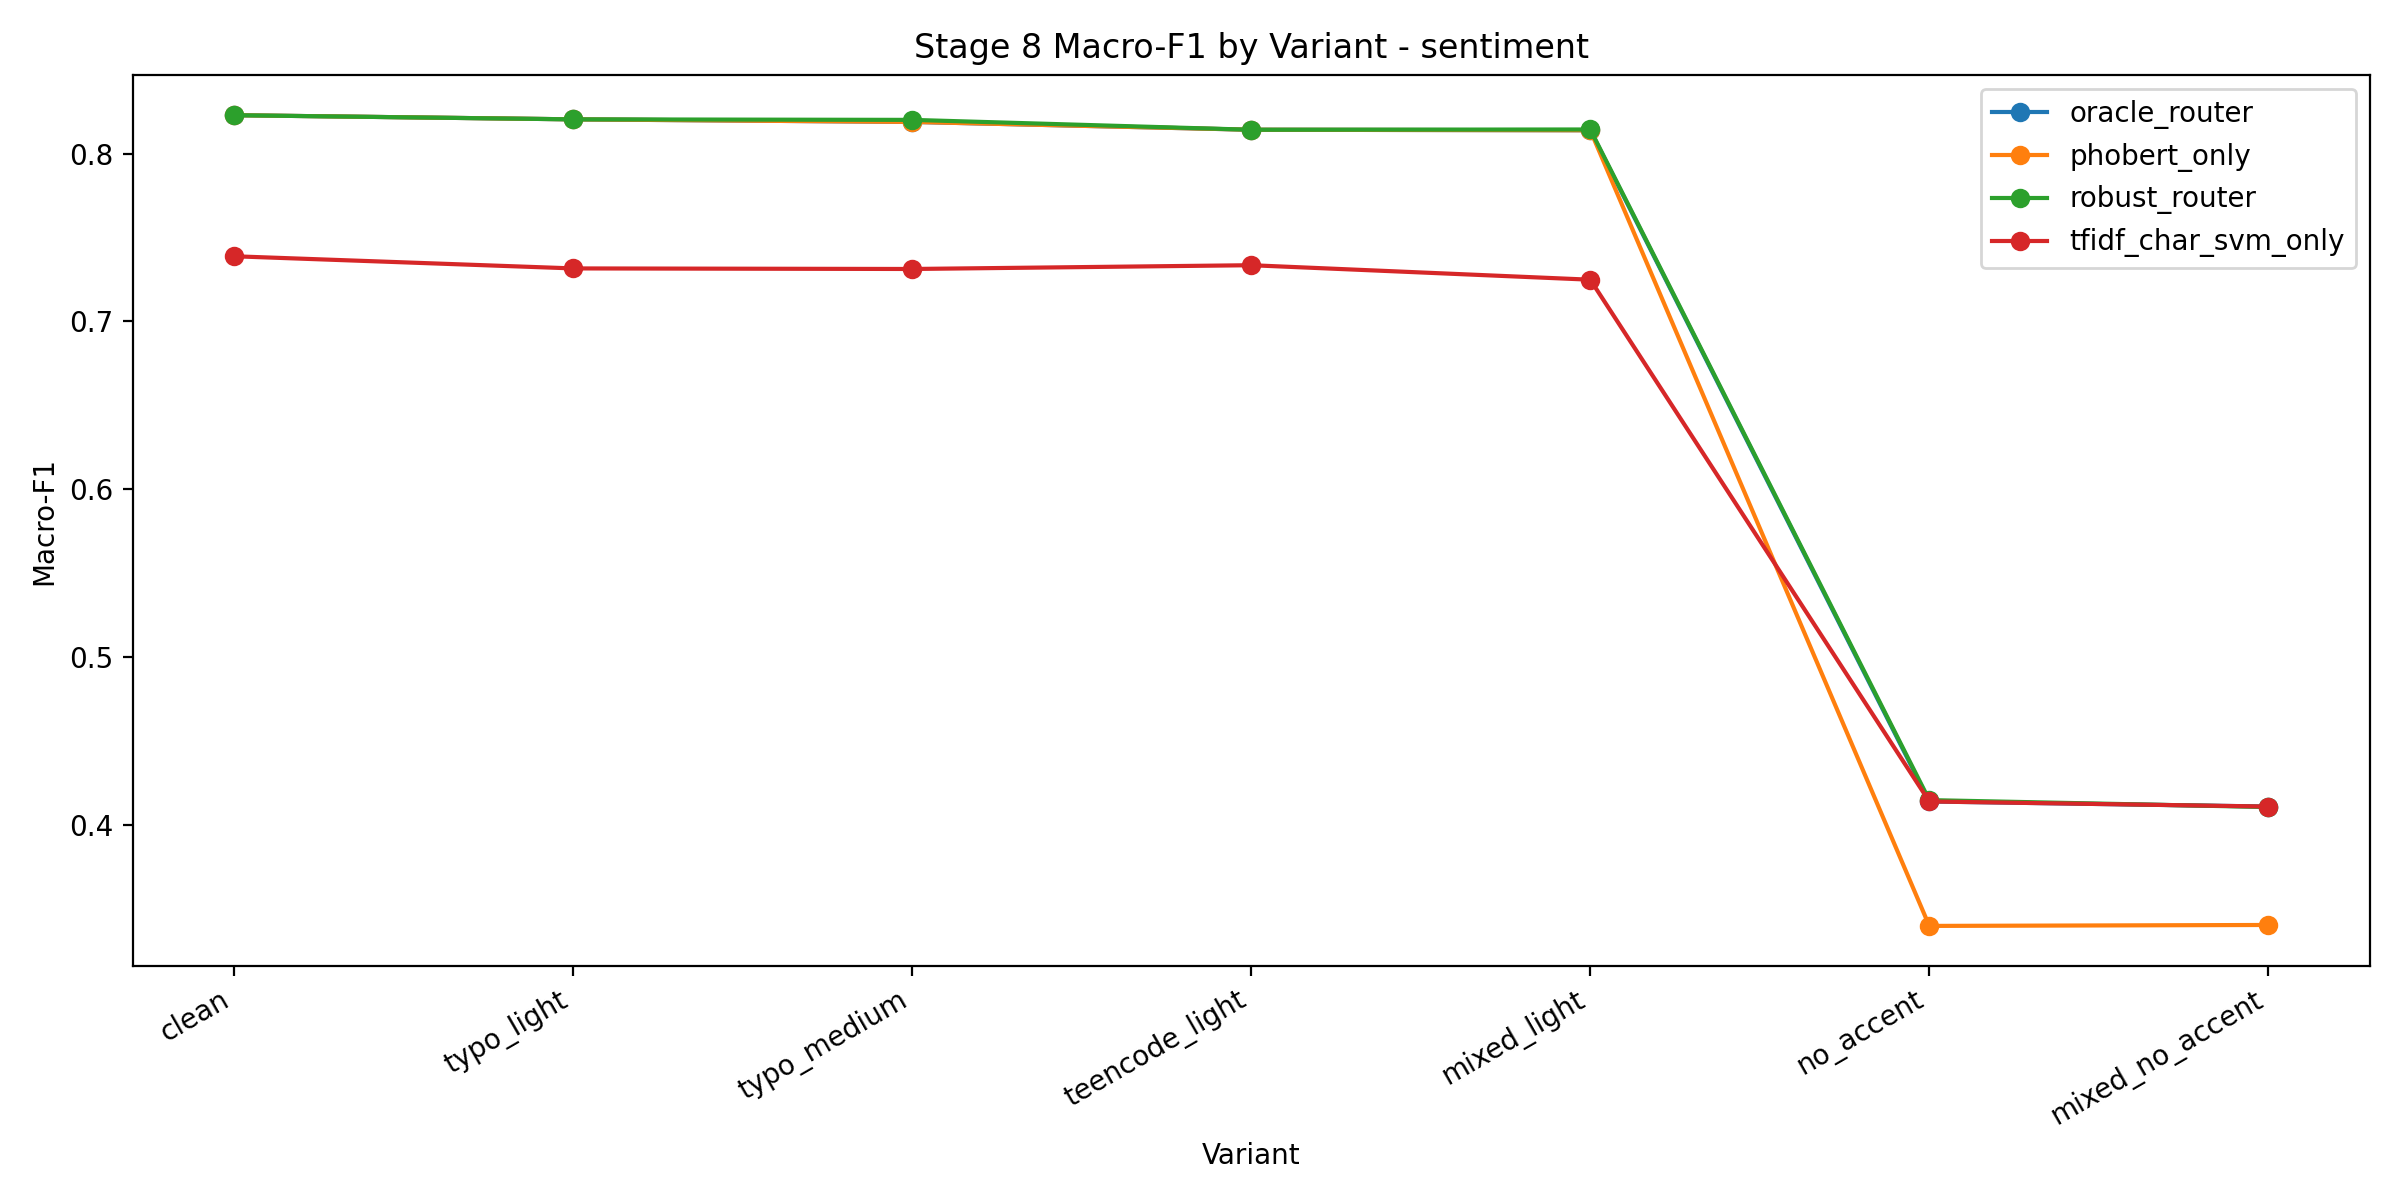

### Topic Macro-F1

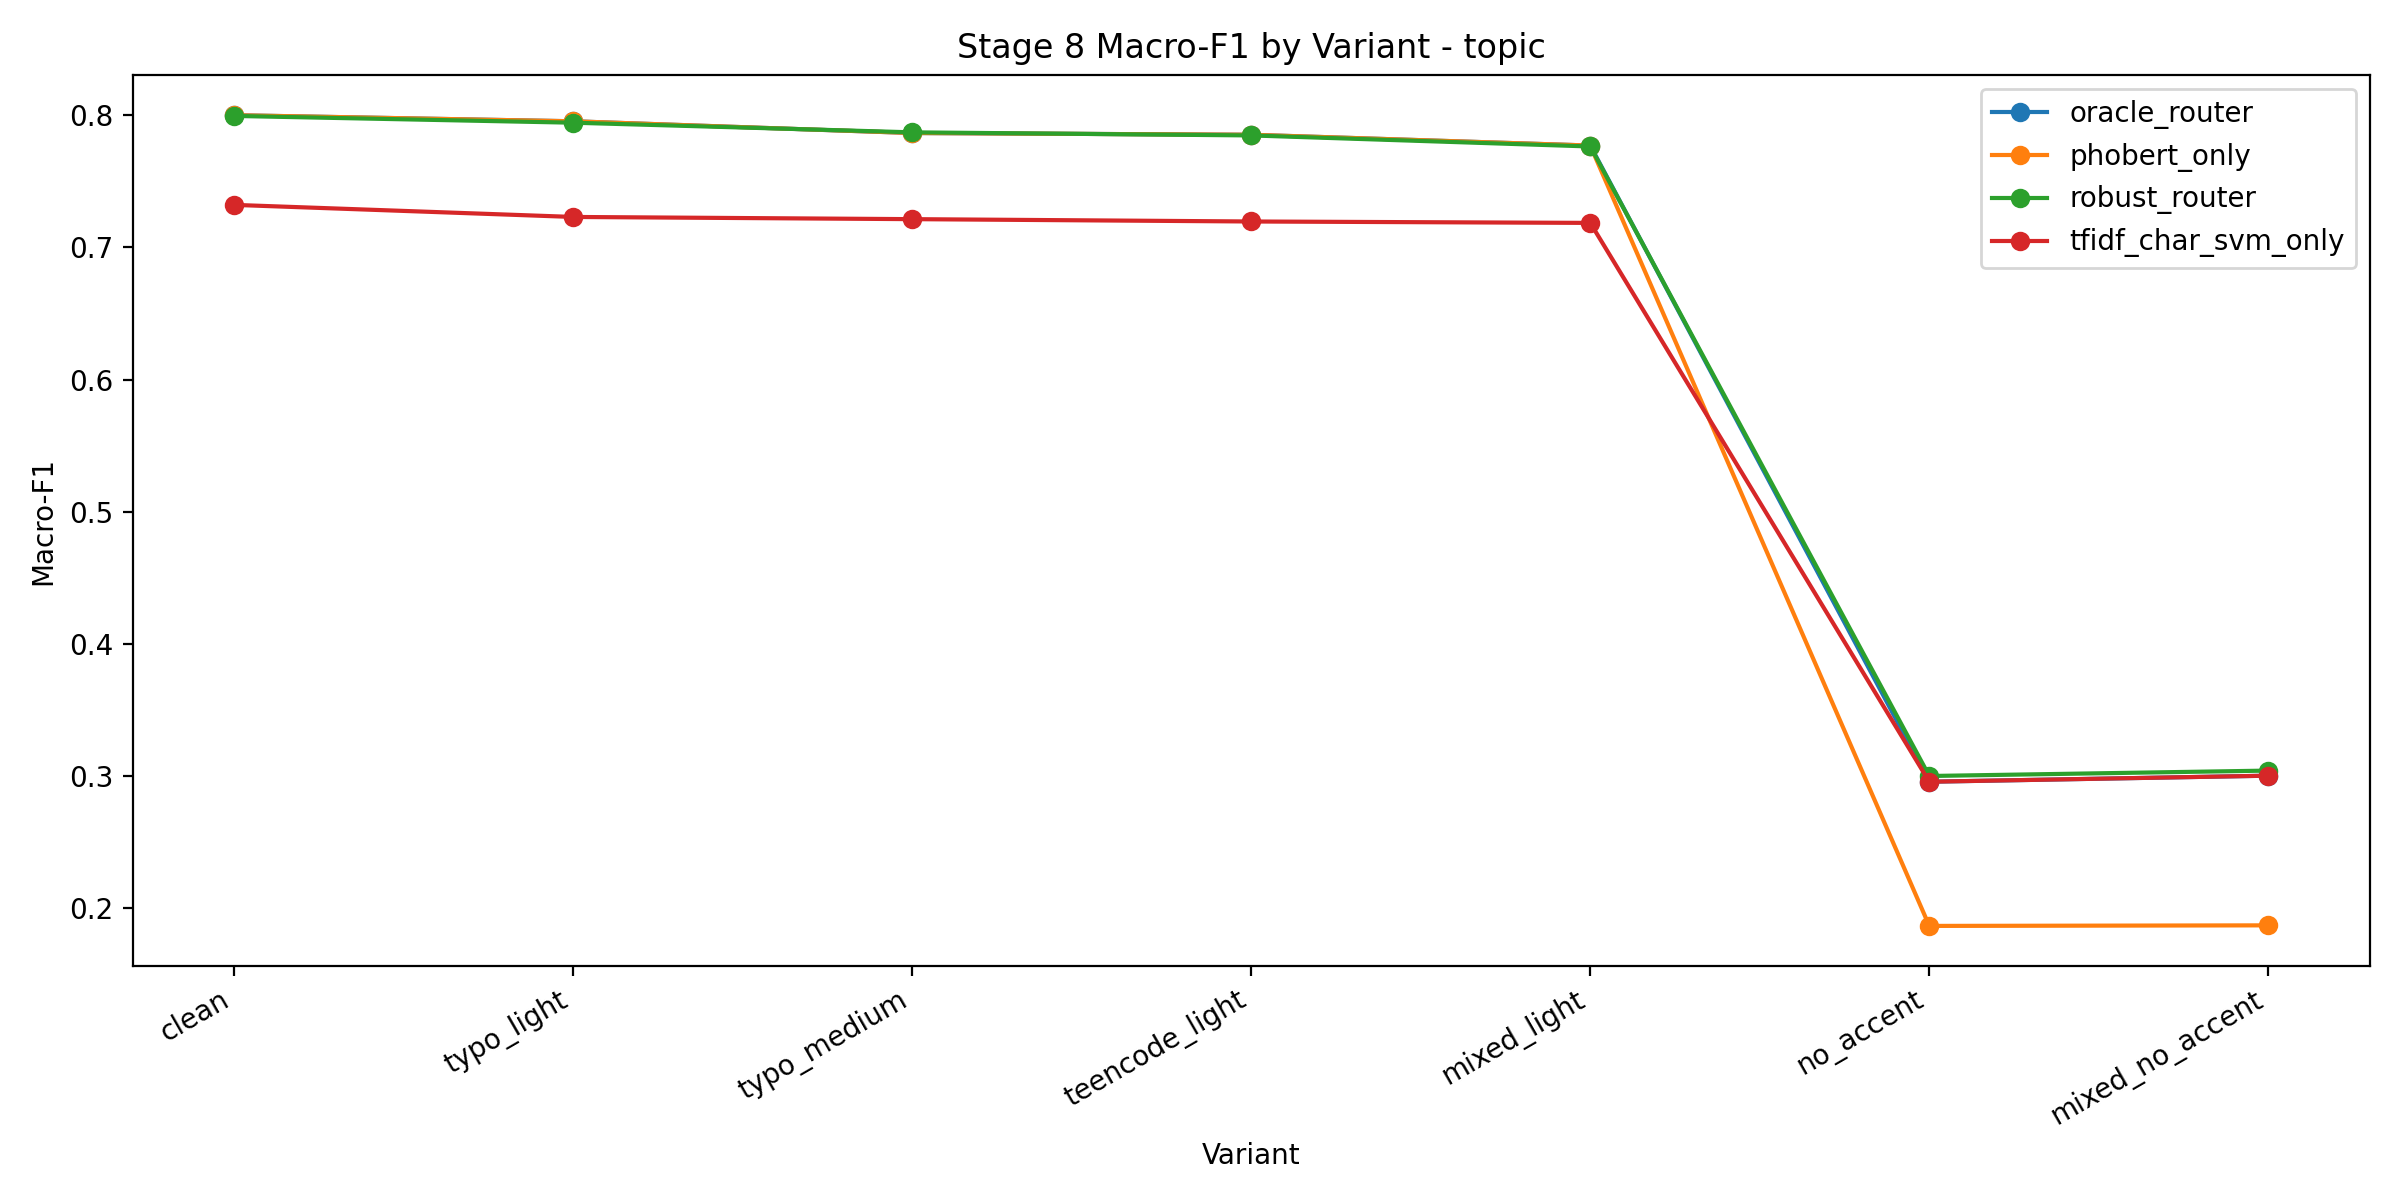

In [10]:
display(Markdown("### Sentiment Macro-F1"))
display(Image(filename=str(FIGURES_DIR / "robust_inference_macro_f1_sentiment.png")))

display(Markdown("### Topic Macro-F1"))
display(Image(filename=str(FIGURES_DIR / "robust_inference_macro_f1_topic.png")))

## 10. Macro-F1 drop visualization

### Sentiment Macro-F1 drop

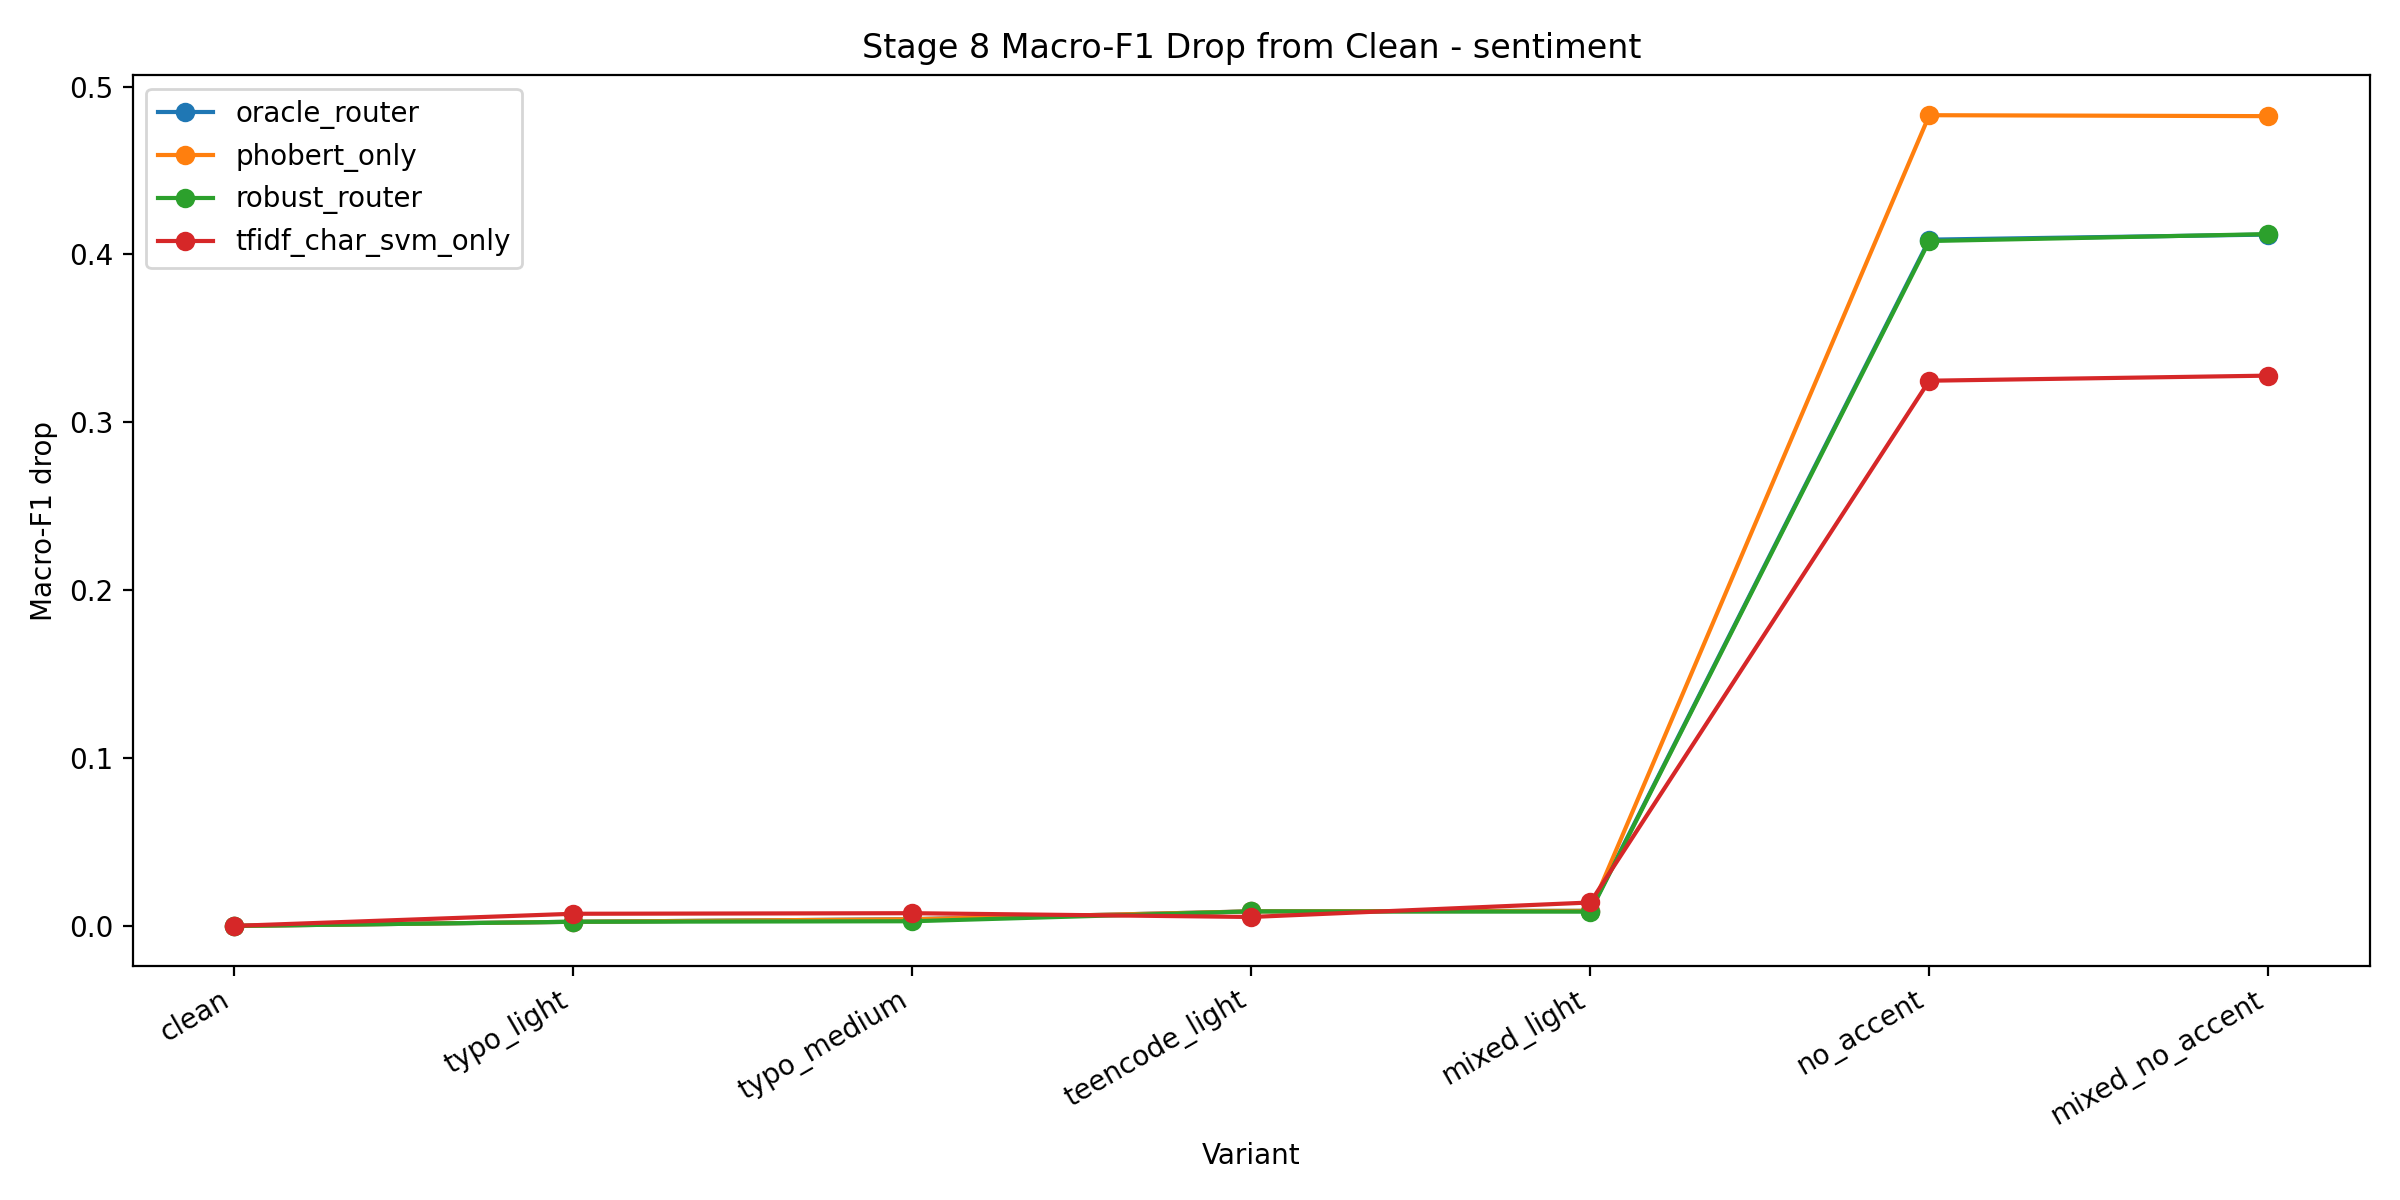

### Topic Macro-F1 drop

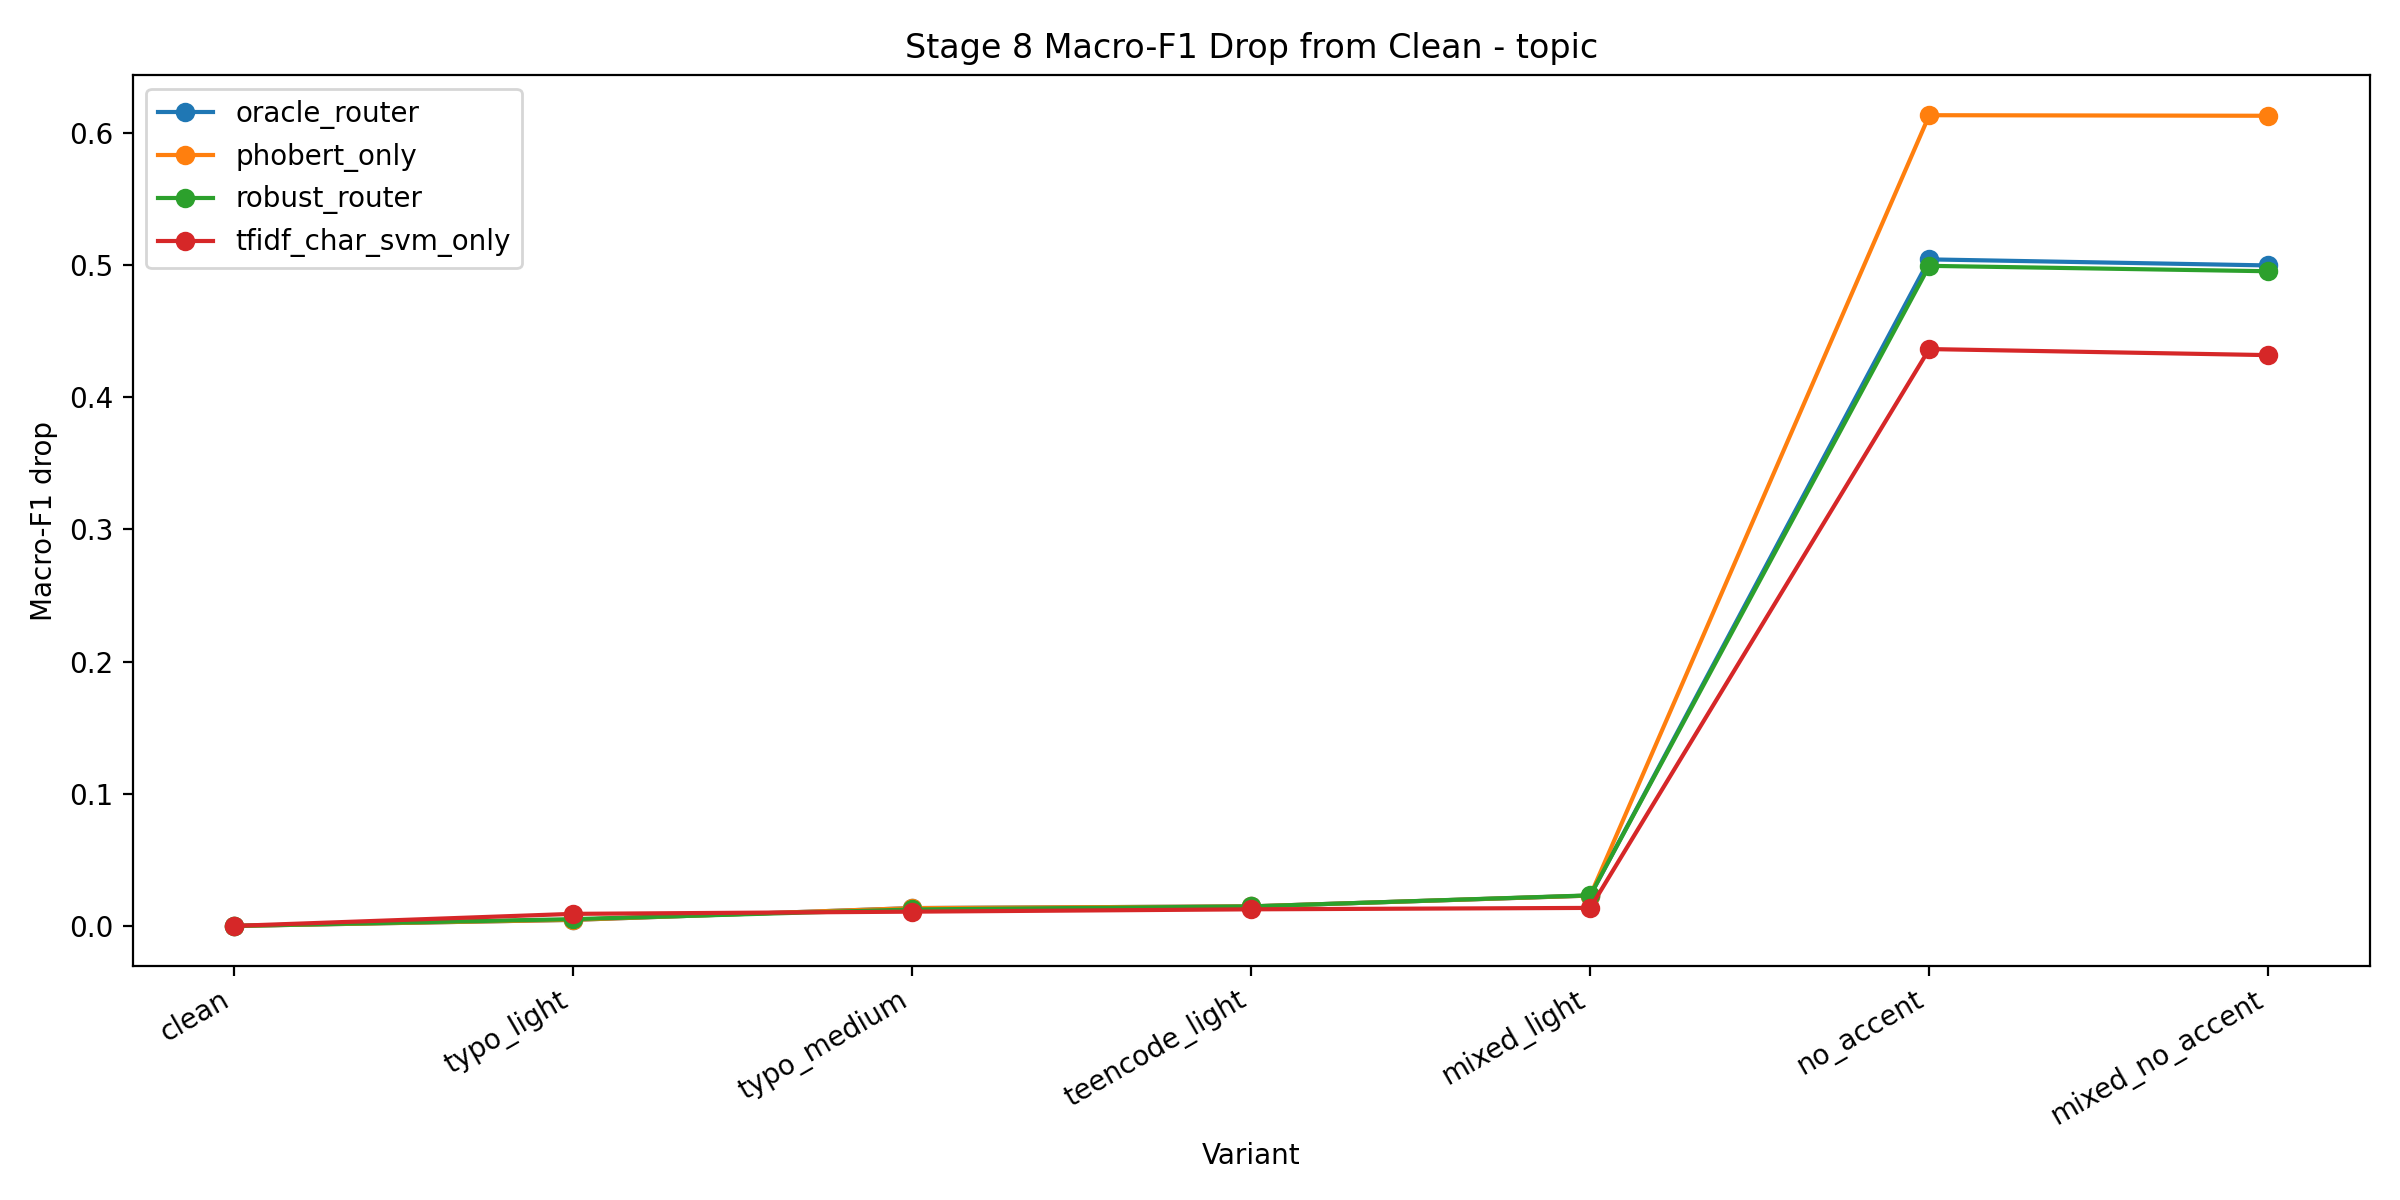

In [11]:
display(Markdown("### Sentiment Macro-F1 drop"))
display(Image(filename=str(FIGURES_DIR / "robust_inference_drop_sentiment.png")))

display(Markdown("### Topic Macro-F1 drop"))
display(Image(filename=str(FIGURES_DIR / "robust_inference_drop_topic.png")))

## 11. Clean/noise nhẹ có bị ảnh hưởng không?

Mục tiêu: kiểm tra robust_router có làm giảm hiệu năng trên clean/noise nhẹ hay không.

In [12]:
light_variants = ["clean", "typo_light", "typo_medium", "teencode_light", "mixed_light"]

light_check = comparison[
    (comparison["system"] == "robust_router") &
    (comparison["variant"].isin(light_variants))
].copy()

light_check = light_check.sort_values(["task", "variant"])

display(light_check[[
    "task",
    "variant",
    "macro_f1",
    "macro_f1_gain_vs_phobert",
    "accuracy",
    "accuracy_gain_vs_phobert",
]])

max_abs_loss = (
    light_check.assign(loss_vs_phobert=-light_check["macro_f1_gain_vs_phobert"])
    .sort_values("loss_vs_phobert", ascending=False)
    .head(1)
)

display(Markdown("### Largest Macro-F1 loss vs PhoBERT-only on clean/light variants"))
display(max_abs_loss[[
    "task",
    "variant",
    "macro_f1_gain_vs_phobert",
    "accuracy_gain_vs_phobert",
]])

,task,variant,macro_f1,macro_f1_gain_vs_phobert,accuracy,accuracy_gain_vs_phobert
2,sentiment,clean,0.822803,-0.000012,0.931459,0.000000
16,sentiment,mixed_light,0.814312,0.000473,0.921668,0.000000
14,sentiment,teencode_light,0.814139,-0.000013,0.924826,0.000000
6,sentiment,typo_light,0.820340,-0.000012,0.929248,0.000000
8,sentiment,typo_medium,0.820027,0.001212,0.927669,0.000316
30,topic,clean,0.799525,-0.000548,0.896083,-0.000316
46,topic,mixed_light,0.776402,-0.000705,0.880922,-0.000316
42,topic,teencode_light,0.784767,-0.000509,0.884713,-0.000315
34,topic,typo_light,0.794399,-0.001077,0.892925,-0.000632
36,topic,typo_medium,0.787098,0.000508,0.885660,0.000316


### Largest Macro-F1 loss vs PhoBERT-only on clean/light variants

,task,variant,macro_f1_gain_vs_phobert,accuracy_gain_vs_phobert
34,topic,typo_light,-0.001077,-0.000632


## 12. No-accent improvement summary

Mục tiêu: tạo bảng ngắn dùng trực tiếp trong báo cáo.

In [13]:
no_accent_focus = comparison[
    (comparison["system"] == "robust_router") &
    (comparison["variant"].isin(["no_accent", "mixed_no_accent"]))
].copy()

summary = no_accent_focus[[
    "task",
    "variant",
    "macro_f1",
    "phobert_only_macro_f1",
    "macro_f1_gain_vs_phobert",
    "accuracy",
    "phobert_only_accuracy",
    "accuracy_gain_vs_phobert",
    "macro_f1_gap_to_oracle",
]].sort_values(["task", "variant"])

display(summary)

,task,variant,macro_f1,phobert_only_macro_f1,macro_f1_gain_vs_phobert,accuracy,phobert_only_accuracy,accuracy_gain_vs_phobert,macro_f1_gap_to_oracle
26,sentiment,mixed_no_accent,0.410707,0.340462,0.070245,0.469994,0.371762,0.098232,0.000293
20,sentiment,no_accent,0.414838,0.339899,0.074939,0.475679,0.375237,0.100442,-0.000814
52,topic,mixed_no_accent,0.304132,0.187029,0.117103,0.437776,0.244157,0.193619,-0.003850
48,topic,no_accent,0.300043,0.186600,0.113443,0.442198,0.252369,0.189829,-0.004341


## 13. Per-class analysis

Mục tiêu: xem Robust Router thay đổi F1 theo từng lớp như thế nào.

In [14]:
summary_labels = {"accuracy", "macro avg", "weighted avg"}
pc = class_report[~class_report["label"].isin(summary_labels)].copy()

focus_pc = pc[
    (pc["system"].isin(["phobert_only", "robust_router"])) &
    (pc["variant"].isin(["clean", "no_accent", "mixed_no_accent"]))
].copy()

for task in focus_pc["task"].dropna().unique():
    display(Markdown(f"### Per-class F1 — {task}"))
    task_df = focus_pc[focus_pc["task"] == task]
    pivot = task_df.pivot_table(
        index=["variant", "label"],
        columns="system",
        values="f1_score",
        observed=False,
    ).reset_index()
    if "phobert_only" in pivot.columns and "robust_router" in pivot.columns:
        pivot["router_minus_phobert"] = pivot["robust_router"] - pivot["phobert_only"]
    display(pivot)

### Per-class F1 — sentiment

system,variant,label,phobert_only,robust_router,router_minus_phobert
0,clean,negative,0.950335,0.950000,-0.000335
1,clean,neutral,0.568627,0.568627,0.000000
2,clean,positive,0.949482,0.949780,0.000298
3,mixed_no_accent,negative,0.324734,0.522917,0.198183
4,mixed_no_accent,neutral,0.141935,0.153981,0.012046
5,mixed_no_accent,positive,0.554717,0.555224,0.000507
6,no_accent,negative,0.309268,0.532967,0.223699
7,no_accent,neutral,0.144391,0.157989,0.013598
8,no_accent,positive,0.566038,0.553558,-0.012480


### Per-class F1 — topic

system,variant,label,phobert_only,robust_router,router_minus_phobert
0,clean,facility,0.924138,0.924138,0.000000
1,clean,lecturer,0.943552,0.943322,-0.000230
2,clean,others,0.546763,0.544803,-0.001960
3,clean,training_program,0.785838,0.785838,0.000000
4,mixed_no_accent,facility,0.147368,0.211454,0.064086
5,mixed_no_accent,lecturer,0.389628,0.604875,0.215247
6,mixed_no_accent,others,0.117701,0.145455,0.027754
7,mixed_no_accent,training_program,0.093418,0.254743,0.161325
8,no_accent,facility,0.136842,0.196429,0.059587
9,no_accent,lecturer,0.405263,0.612115,0.206852


## 14. Kết luận Stage 8

Kết luận rút ra từ kết quả:

```text
1. Detector thiếu dấu được chọn ngưỡng trên noisy validation, không dùng noisy test.
2. Detector route rất ít mẫu clean/noise nhẹ sang char SVM.
3. Detector route phần lớn no_accent/mixed_no_accent sang char SVM.
4. Robust Router gần như giữ nguyên hiệu năng của PhoBERT trên clean/noise nhẹ.
5. Robust Router cải thiện rõ trên no_accent và mixed_no_accent.
6. Stage 8 cải thiện hệ thống suy luận, không cải thiện bản thân PhoBERT.
```

Câu diễn giải an toàn cho báo cáo:

```text
Chiến lược robust inference sử dụng PhoBERT làm mô hình mặc định và chuyển sang TF-IDF char SVM khi đầu vào có khả năng thiếu dấu. Kết quả cho thấy cách kết hợp này giữ được hiệu năng cao của PhoBERT trên dữ liệu chuẩn và nhiễu nhẹ, đồng thời cải thiện đáng kể trên các biến thể thiếu dấu.
```

## 15. Stage 8 status

Stage 8 hoàn thành khi có đủ:

```text
configs/robust_inference.yaml
src/robust_inference.py
scripts/generate_noisy_validation.py
scripts/evaluate_robust_inference.py

data/noisy/validation_eval_all.csv

outputs/tables/noisy_validation_generation_summary.csv
outputs/tables/noisy_validation_detection_thresholds.csv
outputs/tables/robust_inference_detector_overall.csv
outputs/tables/robust_inference_detector_by_variant.csv
outputs/tables/robust_inference_results.csv
outputs/tables/robust_inference_drop.csv
outputs/tables/robust_inference_comparison.csv
outputs/tables/robust_inference_class_report.csv

outputs/predictions/robust_inference_predictions.csv

outputs/figures/robust_inference_macro_f1_sentiment.png
outputs/figures/robust_inference_macro_f1_topic.png
outputs/figures/robust_inference_drop_sentiment.png
outputs/figures/robust_inference_drop_topic.png

outputs/reports/robust_inference_report.md
outputs/metrics/robust_inference_selected_threshold.json
outputs/metrics/robust_inference_metrics.json
```

Sau Stage 8, dự án đủ điều kiện chuyển sang viết báo cáo chính.